# PoC Inferência - Classificação de Calçadas Curitiba (Project Sidewalk)
Este notebook realiza testes exploratórios do modelo do Project Sidewalk em amostras reais de Curitiba.
O foco é testar a viabilidade da classificação binária (Regular vs Irregular) utilizando as classes preditas por eles.

Copiamos os scripts básicos de arquitetura do repositório oficial (`sidewalk_models.py` e a pasta `dinov2`) diretamente para dentro de `scripts/` para que tudo rode de maneira independente.

In [20]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import torchvision.transforms as T

sys.path.append(os.path.abspath('../scripts'))

try:
    from sidewalk_models import DinoVisionTransformerClassifier, CLIP_Classifier
    print("Wrappers locais importados com sucesso!")
except ImportError as e:
    print(f"Erro ao importar os modelos locais: {e}")

Wrappers locais importados com sucesso!


## 1. Configuração e Carregamento do Modelo

Aqui configuramos a arquitetura do modelo DINOv2 e as transformações de imagem exigidas por ele.

**ATENÇÃO:** Para o teste real funcionar, você precisa baixar o arquivo de pesos treinado (`.pth`) e colocá-lo na pasta `data/models/`. Atualize a variável `CAMINHO_PESOS` com o nome correto do arquivo.

In [21]:
# ==========================================
# 1. Configuração do Modelo
# ==========================================

CAMINHO_PESOS = '../data/models/dinov2_base_sidewalk.pth'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Transformações de imagem (DINOv2 exige múltiplos de 14 para o patch de atenção)
# 518x518 é um múltiplo de 14 próximo do usado no treinamento original
transform = T.Compose([
    T.Resize((518, 518)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def carregar_modelo_real(caminho_pesos, device=DEVICE):
    if os.path.exists(caminho_pesos):
        print(f"Carregando pesos de {caminho_pesos}...")
        model_load = torch.load(caminho_pesos, map_location=torch.device(device))
        
        # O número de classes (nc) muda dependendo se o modelo é de SurfaceProblem, Obstacle, etc.
        # Descobrimos dinamicamente lendo o tamanho da última camada nos pesos
        state_dict = model_load.get('model_state_dict', model_load)
        nc = state_dict['classifier.2.bias'].shape[0]
        print(f"Detectado modelo com {nc} classes.")
        
        model = DinoVisionTransformerClassifier("base", nc)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()
        print("Modelo real carregado com sucesso!")
        return model, nc
    else:
        print(f"ERRO: Pesos não encontrados em {caminho_pesos}.")
        print("Por favor, baixe o arquivo de pesos e coloque na pasta indicada.")
        return None, 0

# Instancia o modelo
model, NUM_CLASSES = carregar_modelo_real(CAMINHO_PESOS, DEVICE)

Carregando pesos de ../data/models/dinov2_base_sidewalk.pth...
Detectado modelo com 13 classes.
Modelo real carregado com sucesso!


## 2. Carregamento dos Dados de Teste

Ler o arquivo de metadados das amostras extraídas do Street View em Curitiba.

In [22]:
# ==========================================
# 2. Carregamento dos Dados de Teste
# ==========================================
metadata_path = '../data/raw/amostras_metadata.csv'

if not os.path.exists(metadata_path):
    print("Arquivo de metadados não encontrado!")
else:
    df = pd.read_csv(metadata_path)
    display(df.head(10))

,image_id,bairro,label_real_binario
0,xaxim1,Xaxim,Irregular
1,xaxim2,Xaxim,Irregular
2,xaxim3,Xaxim,Regular
3,xaxim4,Xaxim,Irregular
4,xaxim5,Xaxim,Regular
5,centro1,Centro,Regular
6,centro2,Centro,Regular
7,centro3,Centro,Irregular
8,centro4,Centro,Regular
9,centro5,Centro,Irregular


## 3. Inferência (Análise do Modelo - SurfaceProblem)

O modelo treinado pelo Project Sidewalk para **SurfaceProblem** avalia 13 classes/tags de conservação e características da superfície:
1. `brick-cobblestone`
2. `bumpy`
3. `construction`
4. `cracks`
5. `grass`
6. `height-difference`
7. `narrow-sidewalk`
8. `rail-tram-track`
9. `sand-gravel`
10. `uncovered-manhole`
11. `uneven-slanted`
12. `utility-panel`
13. `very-broken`

In [23]:
# ==========================================
# 3. Inferência (Análise do Modelo)
# ==========================================
# Mapeamento oficial das 13 classes do modelo SurfaceProblem (Project Sidewalk)
CLASS_MAP = [
    "brick-cobblestone",
    "bumpy",
    "construction",
    "cracks",
    "grass",
    "height-difference",
    "narrow-sidewalk",
    "rail-tram-track",
    "sand-gravel",
    "uncovered-manhole",
    "uneven-slanted",
    "utility-panel",
    "very-broken"
]

resultados = []

if model is not None:
    for idx, row in df.iterrows():
        try:
            # 1. Carrega imagem e aplica as transformações
            img_path = f"../data/raw/amostras/{row['image_id']}.png"
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(DEVICE)
            
            # 2. Passa pelo modelo
            with torch.no_grad():
                outputs = model(img_tensor)
                # Aplicamos Sigmoid para ter probabilidades
                probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
            
            # 3. Armazenamos as probabilidades com os nomes oficiais das classes
            res_dict = {
                'image_id': row['image_id'],
                'bairro': row.get('bairro', '')
            }
            
            for i, p in enumerate(probs):
                col_name = CLASS_MAP[i] if i < len(CLASS_MAP) else f'Class_{i}'
                res_dict[col_name] = p
                
            resultados.append(res_dict)
            
        except Exception as e:
            print(f"Erro processando imagem {img_path}: {e}")

    df_resultados = pd.DataFrame(resultados)
    display(df_resultados.head(10))
else:
    print("A inferência foi pulada pois o modelo não foi carregado.")

,image_id,bairro,brick-cobblestone,bumpy,construction,cracks,grass,height-difference,narrow-sidewalk,rail-tram-track,sand-gravel,uncovered-manhole,uneven-slanted,utility-panel,very-broken
0,xaxim1,Xaxim,0.004534,0.513631,0.000728,9.838508e-01,0.512119,0.000021,0.000014,2.230090e-07,5.091380e-01,0.000013,0.044446,1.962754e-05,0.000372
1,xaxim2,Xaxim,0.000551,0.000033,0.133158,1.734570e-05,0.543652,0.000124,0.000719,5.838792e-04,3.116408e-03,0.000062,0.000149,2.147450e-05,0.015636
2,xaxim3,Xaxim,0.496237,0.016962,0.001485,1.413825e-04,0.000016,0.000022,0.000003,1.009663e-05,1.065758e-03,0.000008,0.001999,9.857974e-07,0.000003
3,xaxim4,Xaxim,0.000068,0.750354,0.001688,7.445617e-04,0.000049,0.999907,0.000004,1.308673e-05,3.165829e-03,0.000040,0.013637,7.508903e-06,0.003765
4,xaxim5,Xaxim,0.000256,0.000895,0.002032,1.610469e-05,0.000609,0.597794,0.000364,1.877264e-03,1.287427e-06,0.000130,0.000202,4.115062e-05,0.000498
5,centro1,Centro,0.097050,0.004994,0.003307,3.218033e-05,0.000003,0.000086,0.009737,2.557061e-03,1.315252e-03,0.000853,0.000057,5.758445e-05,0.000427
6,centro2,Centro,0.001251,0.003079,0.000241,1.021033e-06,0.000128,0.135273,0.000113,1.361164e-04,1.421196e-07,0.000006,0.003510,1.528697e-06,0.000002
7,centro3,Centro,0.035927,0.000278,0.001019,5.246082e-06,0.000701,0.000728,0.000249,1.414712e-04,8.482564e-06,0.000011,0.001107,1.281228e-06,0.000003
8,centro4,Centro,0.719052,0.990269,0.018850,1.881199e-07,0.000006,0.000049,0.001317,9.047916e-04,1.835761e-05,0.000111,0.009007,1.142477e-04,0.000054
9,centro5,Centro,0.057272,0.000066,0.029827,2.681192e-03,0.000071,0.000121,0.002832,1.334569e-04,2.288530e-01,0.000187,0.004441,2.181510e-05,0.000613


## 4. Diagnóstico Visual das Probabilidades

Para cada imagem, vamos visualizar as top 3 classes preditas com maior probabilidade pelo modelo para entender quais características da calçada ele está destacando.

Exibindo imagens e as top 3 classes detectadas:


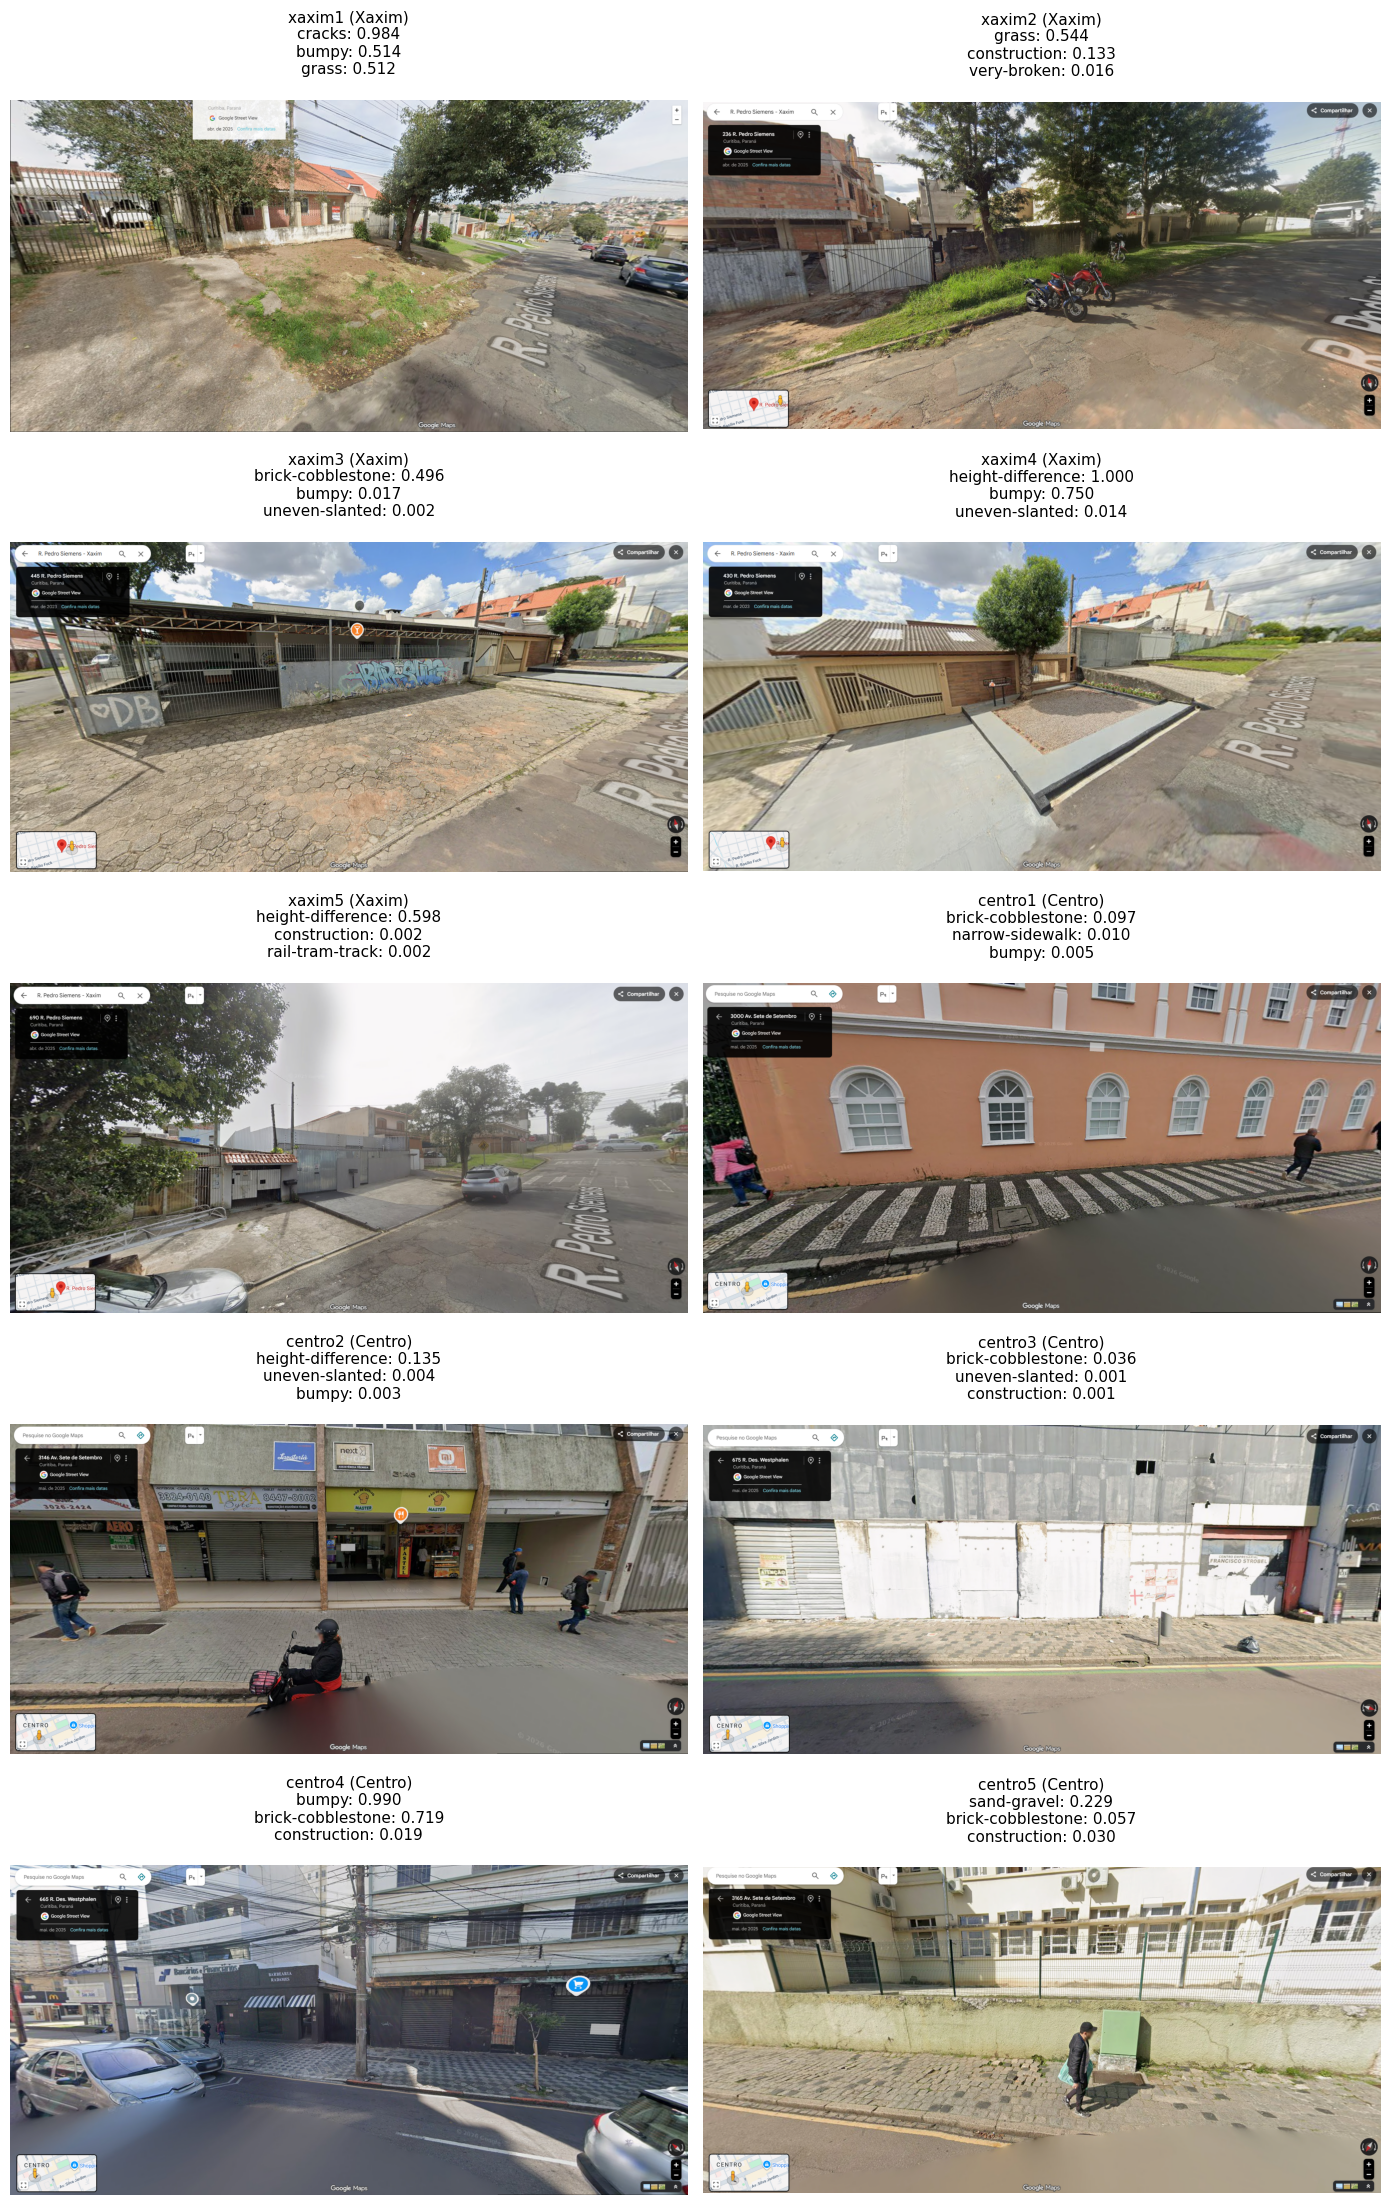

In [24]:
# ==========================================
# 4. Diagnóstico Visual
# ==========================================
CLASS_MAP = [
    "brick-cobblestone",
    "bumpy",
    "construction",
    "cracks",
    "grass",
    "height-difference",
    "narrow-sidewalk",
    "rail-tram-track",
    "sand-gravel",
    "uncovered-manhole",
    "uneven-slanted",
    "utility-panel",
    "very-broken"
]

if len(resultados) == 0:
    print("Nenhum resultado para exibir.")
else:
    print("Exibindo imagens e as top 3 classes detectadas:")
    
    num_plots = min(len(resultados), 10)
    cols = 2
    rows = (num_plots + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows))
    
    # Garantir que axes seja um array plano iterável mesmo com 1 linha
    if rows == 1:
        axes = np.atleast_1d(axes)
    else:
        axes = axes.flatten()
        
    for ax, res in zip(axes, resultados[:num_plots]):
        # Se a imagem existir, mostramos, senão imagem cinza
        img_path = f"../data/raw/amostras/{res['image_id']}.png"
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.imshow(np.full((224, 224, 3), 200, dtype=np.uint8))
            
        # Pega as probabilidades de classe (compatível com nomes oficiais e Class_i)
        ignored_keys = {'image_id', 'bairro'}
        scores = {}
        for k, v in res.items():
            if k in ignored_keys:
                continue
            if k.startswith('Class_'):
                try:
                    idx = int(k.split('_')[1])
                    class_name = CLASS_MAP[idx] if idx < len(CLASS_MAP) else k
                except (ValueError, IndexError):
                    class_name = k
                scores[class_name] = v
            else:
                scores[k] = v
                
        top3 = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:3]
        
        title = f"{res['image_id']} ({res.get('bairro', '')})\n"
        for class_name, score in top3:
            title += f"{class_name}: {score:.3f}\n"
            
        ax.set_title(title, fontsize=11)
        ax.axis('off')
        
    # Esconder eixos vazios se houver
    for i in range(num_plots, len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()